<a href="https://colab.research.google.com/github/7amokarim/Protein-Family-Classification/blob/main/blast_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install biopython -q

In [ ]:
import urllib.request, urllib.parse, time
from Bio import SeqIO

def download_and_trim(query, label, max_seqs=200):
    url = (
        "https://rest.uniprot.org/uniprotkb/stream?"
        f"query={urllib.parse.quote(query + ' AND organism_id:9606 AND reviewed:true')}"
        "&format=fasta"
    )
    urllib.request.urlretrieve(url, f"{label}.fasta")
    records, current = [], []
    with open(f"{label}.fasta") as f:
        for line in f:
            if line.startswith(">"):
                if current: records.append("".join(current))
                if len(records) == max_seqs: break
                current = [line]
            else:
                current.append(line)
    with open(f"{label}.fasta", "w") as f:
        f.writelines(records)
    print(f"✅ {label}: {len(records)} sequences")
    time.sleep(2)

download_and_trim("family:kinase",     "kinases")
download_and_trim("family:peptidase",  "proteases")
download_and_trim("keyword:KW-0813",   "transporters")
download_and_trim("keyword:KW-0675",   "receptors")

✅ kinases: 200 sequences
✅ proteases: 200 sequences
✅ transporters: 200 sequences
✅ receptors: 200 sequences


In [ ]:
import pandas as pd
from Bio import SeqIO
from sklearn.model_selection import train_test_split

records = []
for label in ["kinases", "proteases", "transporters", "receptors"]:
    for rec in SeqIO.parse(f"{label}.fasta", "fasta"):
        seq = str(rec.seq)
        if 50 <= len(seq) <= 1000:
            records.append({"id": rec.id, "sequence": seq, "label": label})

df = pd.DataFrame(records)

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=42)

print(f"Train: {len(train_df)}")
print(f"Test : {len(test_df)}")
print(f"\n{train_df['label'].value_counts()}")

Train: 531
Test : 133

label
proteases       149
transporters    131
receptors       129
kinases         122
Name: count, dtype: int64


In [ ]:
#Setting up the training database as
with open("train.fasta", "w") as f:
    for _, row in train_df.iterrows():
        f.write(f">{row['id']}|{row['label']}\n{row['sequence']}\n")

# حفظ test كـ queries
with open("test.fasta", "w") as f:
    for _, row in test_df.iterrows():
        f.write(f">{row['id']}|{row['label']}\n{row['sequence']}\n")

print(f"✅ train.fasta: {len(train_df)} sequences")
print(f"✅ test.fasta : {len(test_df)} sequences")

✅ kinases: 200 sequences
✅ proteases: 200 sequences
✅ transporters: 200 sequences
✅ receptors: 200 sequences


In [ ]:
with open("train.fasta", "w") as f:
    for _, row in train_df.iterrows():
        f.write(f">{row['id']}|{row['label']}\n{row['sequence']}\n")

with open("test.fasta", "w") as f:
    for _, row in test_df.iterrows():
        f.write(f">{row['id']}|{row['label']}\n{row['sequence']}\n")

print(f"✅ train.fasta: {len(train_df)} sequences")
print(f"✅ test.fasta : {len(test_df)} sequences")

✅ train.fasta: 531 sequences
✅ test.fasta : 133 sequences


In [ ]:
# Install BLAST
!apt-get install -y ncbi-blast+ -q
# Building the database from the train
!makeblastdb -in train.fasta -dbtype prot -out train_db
print("✅ BLAST ready!")

Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  ncbi-data
The following NEW packages will be installed:
  ncbi-blast+ ncbi-data
0 upgraded, 2 newly installed, 0 to remove and 1 not upgraded.
Need to get 15.8 MB of archives.
After this operation, 71.8 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 ncbi-data all 6.1.20170106+dfsg1-9 [3,519 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 ncbi-blast+ amd64 2.12.0+ds-3build1 [12.3 MB]
Fetched 15.8 MB in 0s (63.3 MB/s)
Selecting previously unselected package ncbi-data.
(Reading database ... 118212 files and directories currently installed.)
Preparing to unpack .../ncbi-data_6.1.20170106+dfsg1-9_all.deb ...
Unpacking ncbi-data (6.1.20170106+dfsg1-9) ...
Selecting previously unselected package ncbi-blast+.
Preparing to unpack .../ncbi-blast+_2.12.0+ds-3build1_amd64.deb ...
Unpacking ncb

In [ ]:
!blastp -query test.fasta -db train_db -out blast_results.txt -outfmt 6 -max_target_seqs 1 -evalue 0.001

print("✅ BLAST done!")

✅ BLAST done!


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

# Reading BLAST results
cols = ["query","subject","pident","length","mismatch","gapopen",
        "qstart","qend","sstart","send","evalue","bitscore"]
blast_df = pd.read_csv("blast_results.txt", sep="\t", names=cols)

# Extracting labels
blast_df["true_label"]  = blast_df["query"].str.split("|").str[-1]
blast_df["pred_label"]  = blast_df["subject"].str.split("|").str[-1]

# The sequences that BLAST did not find a result for
all_test = test_df.copy()
all_test["true_label"] = all_test["label"]
matched = blast_df.drop_duplicates("query")[["query","true_label","pred_label"]]

# calculate metrics
y_true = matched["true_label"]
y_pred = matched["pred_label"]

print(f"Sequences matched : {len(matched)} / {len(test_df)}")
print(f"Accuracy          : {accuracy_score(y_true, y_pred):.3f}")
print(f"Precision (macro) : {precision_score(y_true, y_pred, average='macro', zero_division=0):.3f}")
print(f"Recall (macro)    : {recall_score(y_true, y_pred, average='macro', zero_division=0):.3f}")

Sequences matched : 106 / 133
Accuracy          : 0.934
Precision (macro) : 0.925
Recall (macro)    : 0.930


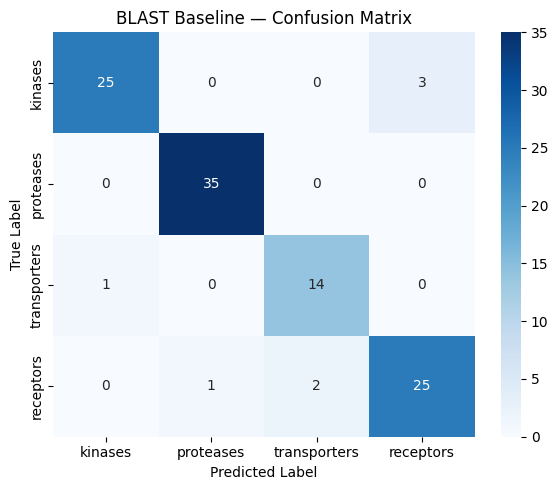

✅ Saved!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

labels = ["kinases", "proteases", "transporters", "receptors"]
cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.title("BLAST Baseline — Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("blast_confusion_matrix.png")
plt.show()
print("✅ Saved!")